# EDA


## Libraries Used


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


## Load Dataset


In [2]:
data = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['ChurnNumeric'] = data['Churn'].map({'Yes': 1, 'No': 0})

print('Dataset shape:', data.shape)
display(data.head())


Dataset shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnNumeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Check Missing Values


In [3]:
print(data.isnull().sum())


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
ChurnNumeric         0
dtype: int64


## Churn Distribution


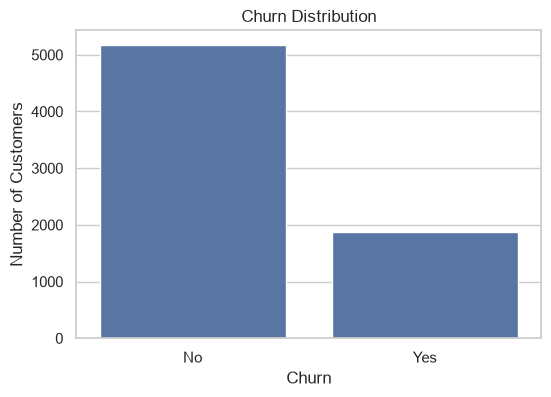

Overall churn rate: 0.2653698707936959


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

churn_rate = data['ChurnNumeric'].mean()
print('Overall churn rate:', churn_rate)


## Churn Rate By Contract


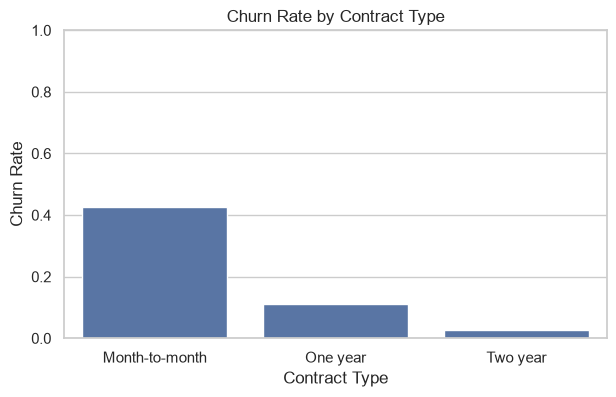

,Contract,ChurnNumeric
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


In [5]:
contract_churn = data.groupby('Contract')['ChurnNumeric'].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=contract_churn, x='Contract', y='ChurnNumeric')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

display(contract_churn)


## Churn Rate By Tenure Group


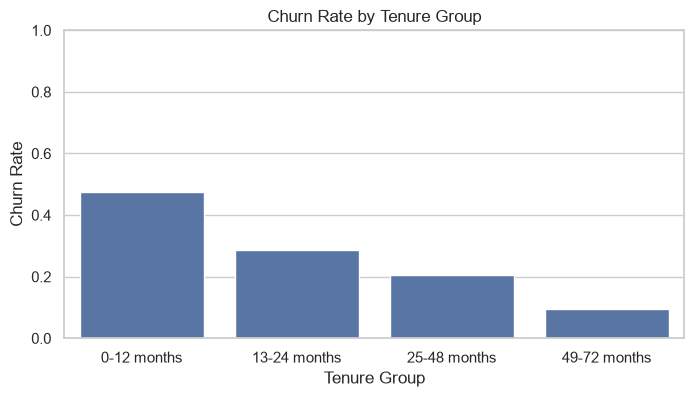

,TenureGroup,ChurnNumeric
0,0-12 months,0.474382
1,13-24 months,0.287109
2,25-48 months,0.203890
3,49-72 months,0.095132


In [6]:
data['TenureGroup'] = pd.cut(
    data['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True
)

tenure_churn = data.groupby('TenureGroup', observed=False)['ChurnNumeric'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=tenure_churn, x='TenureGroup', y='ChurnNumeric')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

display(tenure_churn)


## Monthly Charges By Churn


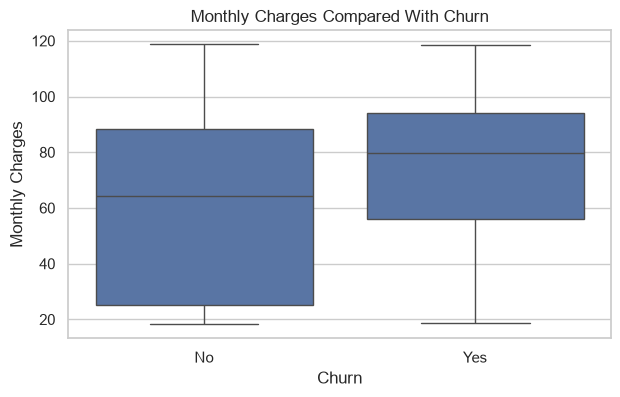

,Churn,MonthlyCharges
0,No,61.265124
1,Yes,74.441332


In [7]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges Compared With Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

monthly_summary = data.groupby('Churn')['MonthlyCharges'].mean().reset_index()
display(monthly_summary)


## Total Charges By Churn


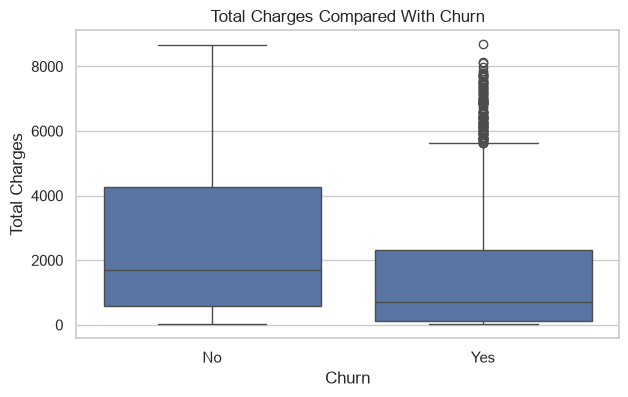

,Churn,TotalCharges
0,No,2555.344141
1,Yes,1531.796094


In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x='Churn', y='TotalCharges')
plt.title('Total Charges Compared With Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

total_summary = data.groupby('Churn')['TotalCharges'].mean().reset_index()
display(total_summary)


## Churn Rate By Internet Service


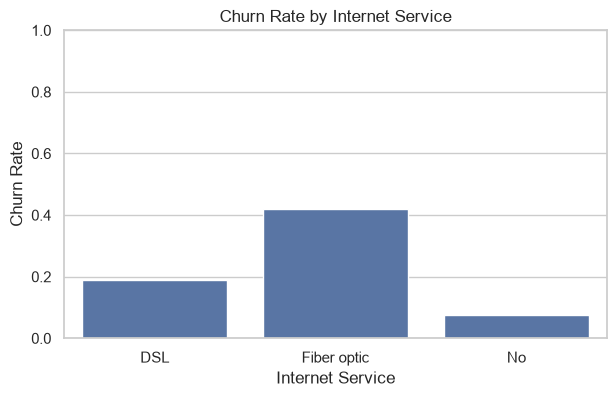

,InternetService,ChurnNumeric
0,DSL,0.189591
1,Fiber optic,0.418928
2,No,0.074050


In [9]:
internet_churn = data.groupby('InternetService')['ChurnNumeric'].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=internet_churn, x='InternetService', y='ChurnNumeric')
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.show()

display(internet_churn)


## Churn Rate By Payment Method


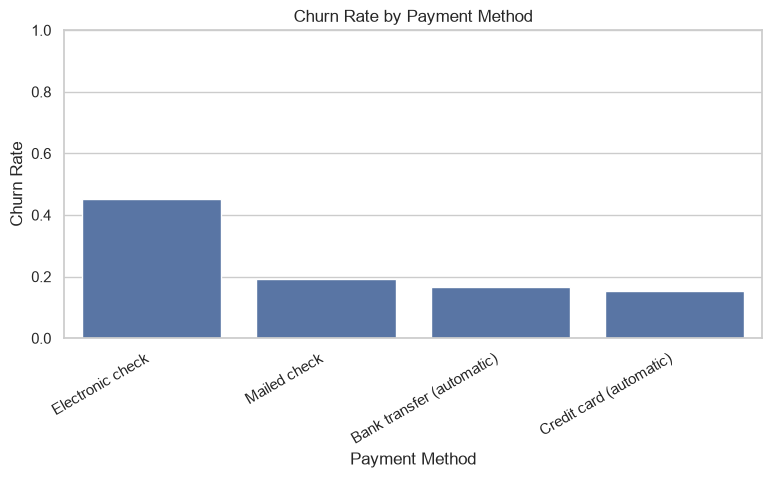

,PaymentMethod,ChurnNumeric
0,Electronic check,0.452854
1,Mailed check,0.191067
2,Bank transfer (automatic),0.167098
3,Credit card (automatic),0.152431


In [10]:
payment_churn = data.groupby('PaymentMethod')['ChurnNumeric'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(9, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='ChurnNumeric')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.show()

display(payment_churn)


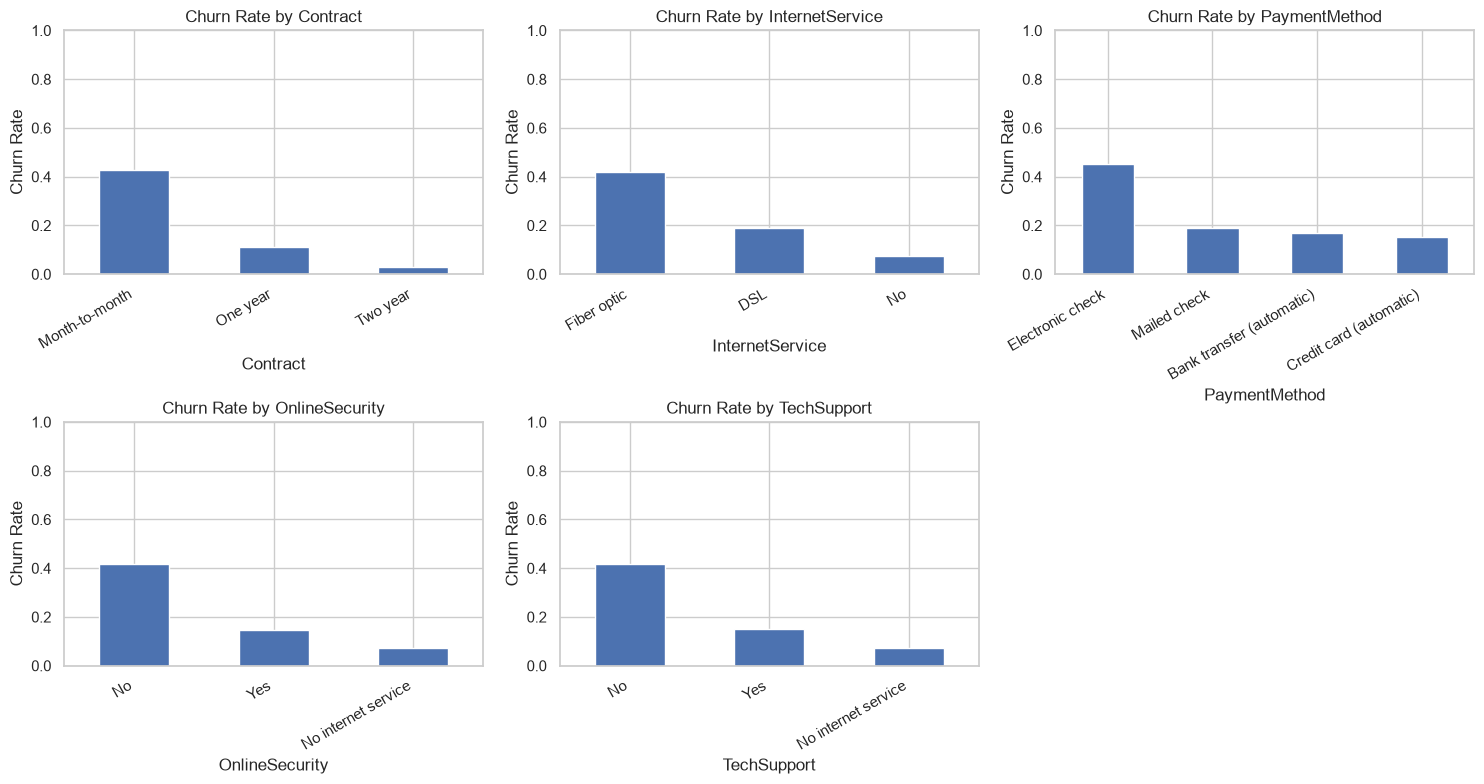

In [11]:
important_categorical_columns = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']

plt.figure(figsize=(15, 8))

for i, column in enumerate(important_categorical_columns, start=1):
    plt.subplot(2, 3, i)
    feature_churn = data.groupby(column)['ChurnNumeric'].mean().sort_values(ascending=False)
    feature_churn.plot(kind='bar')
    plt.title(f'Churn Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


## Correlation Heatmap





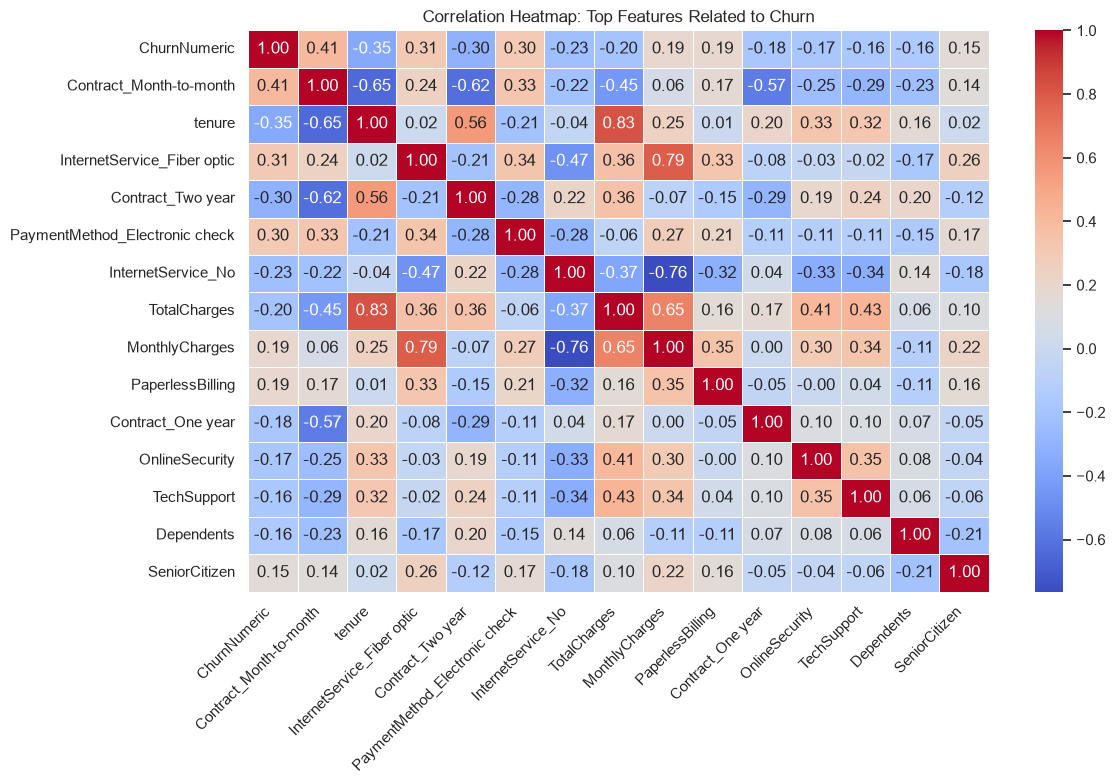

,Feature,Correlation With Churn
0,ChurnNumeric,1.000000
1,Contract_Month-to-month,0.405103
2,tenure,0.352229
3,InternetService_Fiber optic,0.308020
4,Contract_Two year,0.302253
5,PaymentMethod_Electronic check,0.301919
6,InternetService_No,0.227890
7,TotalCharges,0.199037
8,MonthlyCharges,0.193356
9,PaperlessBilling,0.191825


In [12]:
correlation_data = data.copy()

correlation_data['TotalCharges'] = correlation_data['TotalCharges'].fillna(correlation_data['TotalCharges'].median())

binary_map = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0,
    'Male': 1,
    'Female': 0
}

binary_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

for column in binary_columns:
    correlation_data[column] = correlation_data[column].map(binary_map)

correlation_data = pd.get_dummies(
    correlation_data,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    dtype=int
)

correlation_data = correlation_data.drop(columns=['customerID', 'Churn', 'TenureGroup'], errors='ignore')

churn_correlations = correlation_data.corr()['ChurnNumeric'].abs().sort_values(ascending=False)
top_features = churn_correlations.head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_data[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap: Top Features Related to Churn')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(churn_correlations.head(15).reset_index().rename(columns={'index': 'Feature', 'ChurnNumeric': 'Correlation With Churn'}))
